<a href="https://colab.research.google.com/github/nunez1405/Data-science-projects/blob/main/Copia_de_bloque03_03_validacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bloque 03 - Unidad 03: Ajuste de Modelos, Validación, Testing y Selección de Características

En esta clase, vamos a aplicar técnicas de ajuste de modelos, validación cruzada, testing y selección de características para optimizar un modelo de **LogisticRegression** usando el conjunto de datos de **Cáncer de Mama Wisconsin**. El objetivo es mejorar la precisión del modelo y entender mejor cuáles son las características más importantes.


## Dividiendo los datos en Train y Test

Es esencial dividir los datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento de los modelos de manera precisa. El conjunto de entrenamiento se utiliza para ajustar el modelo, mientras que el conjunto de prueba permite medir su capacidad de generalización. La función `train_test_split` facilita esta tarea, permitiendo dividir los datos de manera sencilla y eficiente.

### Ejemplo con polinomio

Generemos datos con un polinomio de grado 1 $\Big( y(x) = 2x + 1 \Big)$,
dividamos en subconjuntos de entrenamiento (*train*) y prueba (*test*),
y ajustemos con un polinomio de grado 5.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

rng = np.random.default_rng(1)

# Generar datos (polinomio de grado 1)
df = pd.DataFrame({"x": np.arange(14)})
df["y"] = 2 * df["x"] + 1 + rng.normal(size=len(df))

# Features y targets
features = ["x"]
targets = "y"

# Crear modelo (polinomio de grado 5)
model = Pipeline(
    [
        ("polynomial", PolynomialFeatures(degree=5)),
        ("regression", LinearRegression()),
    ]
)

# Dividir en train-test
df_train, df_test = train_test_split(df, train_size=0.5, random_state=1)

# Entrenar modelo
model.fit(df_train[features], df_train[targets])

# Evaluar score
print("Train score:", model.score(df_train[features], df_train[targets]))
print(" Test score:", model.score(df_test[features], df_test[targets]))

Train score: 0.9992270813063544
 Test score: 0.568637337704101


El *score* en el conjunto de entrenamiento es alto,
pero sobreajustó estos datos,
ya que el *score* en el conjunto de prueba es menor.

Gráficamente:

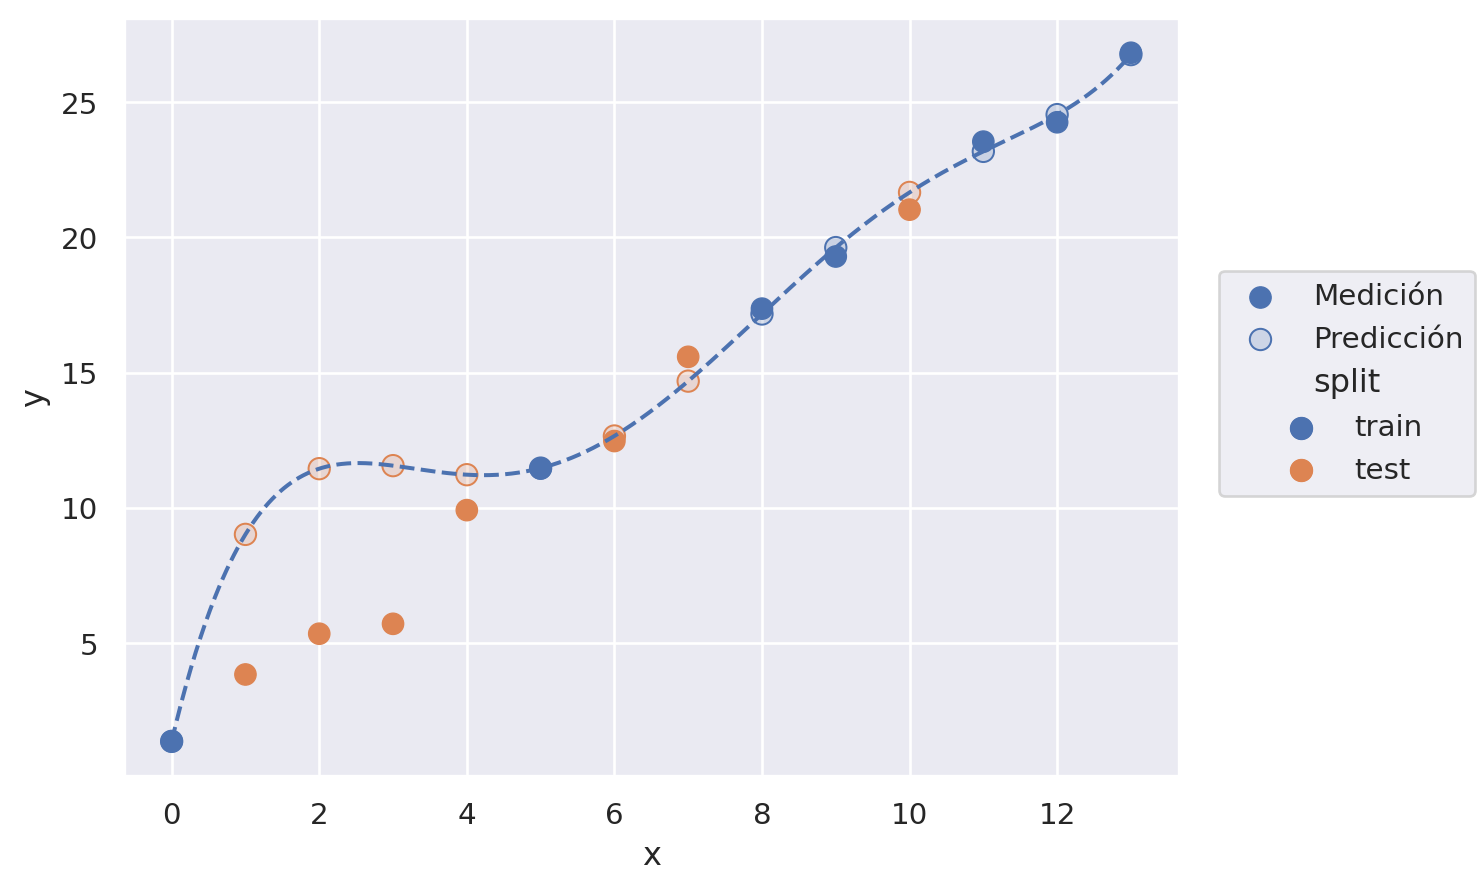

In [ ]:
from matplotlib.figure import Figure
import seaborn
import seaborn.objects as so


# Predecir con el modelo
df = pd.concat(
    [
        df_train.assign(split="train"),
        df_test.assign(split="test"),
    ]
)
df["y_pred"] = model.predict(df[features])

# Evaluar modelo en más puntos
df_eval = pd.DataFrame({"x": np.linspace(df["x"].min(), df["x"].max(), 1000)})
df_eval["y"] = model.predict(df_eval)

# Graficar
seaborn.set_theme()
fig = Figure(layout="tight")
axes = fig.add_subplot()
(
    so.Plot(df, x="x", color="split")
    .add(so.Dot(pointsize=8), y="y", label="Medición")
    .add(so.Dots(pointsize=8), y="y_pred", label="Predicción")
    .on(axes)
    .plot()
)
(
    so.Plot(df_eval, x="x", y="y")
    .add(so.Line(linestyle="--"))
    .on(axes)
    .plot()
)

### Dataset de cáncer de mama

In [ ]:
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Cargar dataset
X, y = datasets.load_breast_cancer(return_X_y=True, as_frame=True)

# Dividir el conjunto de datos en 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=144
)

# Entrenar el modelo con los datos de entrenamiento
model = LogisticRegression(max_iter=5_000)
model.fit(X_train, y_train)

# Evaluar el modelo en los datos de prueba
print("Precisión del modelo:", model.score(X_test, y_test))

Precisión del modelo: 1.0


In [ ]:
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Cargar dataset
X, y = datasets.load_breast_cancer(return_X_y=True, as_frame=True)

# Dividir el conjunto de datos en 80% para entrenamiento y 20% para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=144
)

# Entrenar el modelo con los datos de entrenamiento
model = LogisticRegression(max_iter=5_000)
model.fit(X_train, y_train)

# Evaluar el modelo en los datos de prueba
print("Precisión del modelo:", model.score(X_test, y_test))

Precisión del modelo: 1.0


**Para hacer:**

1. Lee la documentación de `train_test_split`
2. Inspeccioná el contenido de `X_train`, `X_test`, `y_train`, `y_test`
3. ¿Cambia algo si corrés el código de `train_test_split` otra vez? ¿Por qué?
4. ¿Cómo depende el resultado de los parámetros de `train_test_split`?

## Validación Cruzada

La validación cruzada es una técnica utilizada para evaluar el rendimiento de un modelo de machine learning de manera más robusta y evitar el sobreajuste. En lugar de dividir el conjunto de datos en solo dos partes (entrenamiento y prueba), la validación cruzada divide los datos en varios subconjuntos o "folds". El modelo se entrena en algunos de estos subconjuntos y se valida en los restantes, repitiendo el proceso varias veces. Esto permite obtener una evaluación más precisa del rendimiento general del modelo, al usar todos los datos tanto para entrenamiento como para prueba.

Vamos a aplicar la **validación cruzada** para evaluar el rendimiento del modelo de **LogisticRegression**.

**Para hacer:**
1. Buscá la función `cross_val_score` en la documentación.
2. Aplicá esta validación cruzada a la regresión logística de los datos.
```python
scores = cross_val_score(logreg, X, y, cv=5)
````
3. ¿Que hay en scores?
4. Compará los resultados de la validación cruzada con diferentes valores de `cv` (ej. `cv=3`, `cv=5`, `cv=10`). ¿cómo afecta el valor de `cv` a la estabilidad de la precisión?

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=10)
print(scores)

[0.98245614 0.9122807  0.92982456 0.94736842 0.98245614 0.98245614
 0.92982456 0.94736842 0.96491228 0.96428571]


**Para leer en casa**: https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation

## Ajuste de Hiperparámetros

Los hiperparámetros de un modelo son valores configurables que determinan cómo el modelo se entrena y se ajusta a los datos. A diferencia de los parámetros, que se aprenden durante el entrenamiento, los hiperparámetros deben definirse antes del proceso de aprendizaje y afectan el rendimiento final del modelo.

**Para hacer:**

1. Buscá en la documentación cuáles son los hiperparámetros de **LogisticRegression** y que hace cada uno.
2. Usá `train_test_split` para partir los datos.
3. Buscá en la documentación `GridSearchCV` y usalo para optimizar los hiper parametros `C`, `penalty` y `solver`:
```python
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularización
    'penalty': ['l1', 'l2'],       # Penalización L1 o L2
    'solver': ['liblinear']        # Solver compatible con L1 y L2
}
```
4. ¿Cuál es el mejor conjunto de hiperparámetro?
5. ¿Cómo da la matriz de confusión para este modelo?
6. Evaluá el rendimiento del modelo ajustado en el conjunto de prueba y compará los resultados con el modelo base (sin ajuste de hiperparámetros).

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Cargar datos
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Crear pipeline CORRECTO
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=5000, random_state=42))
])

# 4. Definir param_grid CORRECTO (con prefijos)
param_grid = {
    'logistic__C': [0.01, 0.1, 1, 10, 100],
    'logistic__penalty': ['l1', 'l2'],
    'logistic__solver': ['liblinear']  # Solver compatible con L1 y L2
}

# 5. Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# 6. Ejecutar búsqueda
grid_search.fit(X_train, y_train)

# 7. Resultados
print("Mejores parámetros:", grid_search.best_params_)
print(f"Mejor accuracy (validación): {grid_search.best_score_:.4f}")
print(f"Accuracy en test: {grid_search.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros: {'logistic__C': 0.1, 'logistic__penalty': 'l2', 'logistic__solver': 'liblinear'}
Mejor accuracy (validación): 0.9802
Accuracy en test: 0.9825


**Para buscar en casa**: Hay otros métodos de optimización de hiperparámetros como `RandomizedSearchCV`. Buscá en la documentación la diferencia. Tambien hay otros como métodos bayesianos, buscá aca: https://towardsdatascience.com/a-conceptual-explanation-of-bayesian-model-based-hyperparameter-optimization-for-machine-learning-b8172278050f

## Selección de Características

La selección de características es una técnica utilizada en machine learning para identificar y conservar solo las variables más relevantes de un conjunto de datos. Al reducir el número de características innecesarias o redundantes, se mejora la eficiencia del modelo y se evita el sobreajuste, haciendo que el modelo sea más fácil de interpretar y a menudo más preciso. Esto también ayuda a reducir el tiempo de procesamiento y los recursos computacionales necesarios.

Vamos a aplicar **Recursive Feature Elimination (RFE)** para seleccionar las características más importantes para el modelo de **LogisticRegression**.

In [ ]:
from sklearn.feature_selection import RFE


# Aplicar RFE para seleccionar las mejores características
selector = RFE(model, n_features_to_select=5)
selector.fit(X, y)

# Mostrar las características seleccionadas
print(f"Características seleccionadas: {selector.support_}")
print(f"Ranking de las características: {selector.ranking_}")

Características seleccionadas: [ True False False False False False  True False  True False  True False
 False False False False False False False False False False False False
 False False  True False False False]
Ranking de las características: [ 1  4 11 21 20 15  1 12  1 24  1  5 19  9 25 18 16 22 23 26  6  8  2 17
 13  7  1  3 10 14]


**Para hacer:**

1. ¿Cuáles fueron las características seleccionadas con RFE?
2. Evaluá cómo cambia el rendimiento del modelo al reducir el número de características
3. Visualizá las características seleccionas vs. las demás.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import numpy as np

# Cargar datos
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Usar modelo con mejores hiperparámetros encontrados
model = LogisticRegression(C=0.1, penalty='l2', solver='liblinear', max_iter=5000)

# Aplicar RFE para seleccionar 5 características
selector = RFE(model, n_features_to_select=5)
selector.fit(X, y)

# Identificar características seleccionadas
selected_features = feature_names[selector.support_]
selected_idx = np.where(selector.support_)[0]

print("\n=== Resultados RFE ===")
print(f"Características seleccionadas (5): {selected_features}")
print(f"Índices seleccionados: {selected_idx}")
print(f"Ranking completo: {selector.ranking_}")
print(f"Máscara de selección: {selector.support_}")


=== Resultados RFE ===
Características seleccionadas (5): ['mean radius' 'mean concavity' 'mean symmetry' 'radius error'
 'worst concavity']
Índices seleccionados: [ 0  6  8 10 26]
Ranking completo: [ 1  4 11 21 20 15  1 12  1 24  1  5 19  9 25 18 16 22 23 26  6  8  2 17
 13  7  1  3 10 14]
Máscara de selección: [ True False False False False False  True False  True False  True False
 False False False False False False False False False False False False
 False False  True False False False]


Rendimiento con características reducidas

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Modelo con todas las características
full_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=0.1, penalty='l2', solver='liblinear', max_iter=5000)
)
full_scores = cross_val_score(full_model, X, y, cv=10)

# Modelo con solo características seleccionadas
reduced_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=0.1, penalty='l2', solver='liblinear', max_iter=5000)
)
reduced_scores = cross_val_score(reduced_model, X[:, selector.support_], y, cv=10)

print("\n=== Comparación de Rendimiento ===")
print(f"Accuracy con 30 características: {full_scores.mean():.4f} ± {full_scores.std():.4f}")
print(f"Accuracy con 5 características: {reduced_scores.mean():.4f} ± {reduced_scores.std():.4f}")
print(f"Diferencia: {(full_scores.mean() - reduced_scores.mean()):.4f}")


=== Comparación de Rendimiento ===
Accuracy con 30 características: 0.9824 ± 0.0176
Accuracy con 5 características: 0.9227 ± 0.0352
Diferencia: 0.0596


El Cross_validation_score redució significativamente, 5 caracteristcias no son suficientes.


In [ ]:
from sklearn.feature_selection import SelectFromModel

# Entrenar modelo completo
full_model = LogisticRegression(C=0.1, penalty='l2', solver='liblinear')
full_model.fit(X_train, y_train)

# Seleccionar características con importancia > promedio
selector = SelectFromModel(full_model, threshold="mean")
selector.fit(X_train, y_train)

# Características seleccionadas
selected_features = feature_names[selector.get_support()]
print(f"Características seleccionadas ({len(selected_features)}):")
print(selected_features)

Características seleccionadas (9):
['mean radius' 'mean perimeter' 'mean concavity' 'texture error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst compactness'
 'worst concavity']


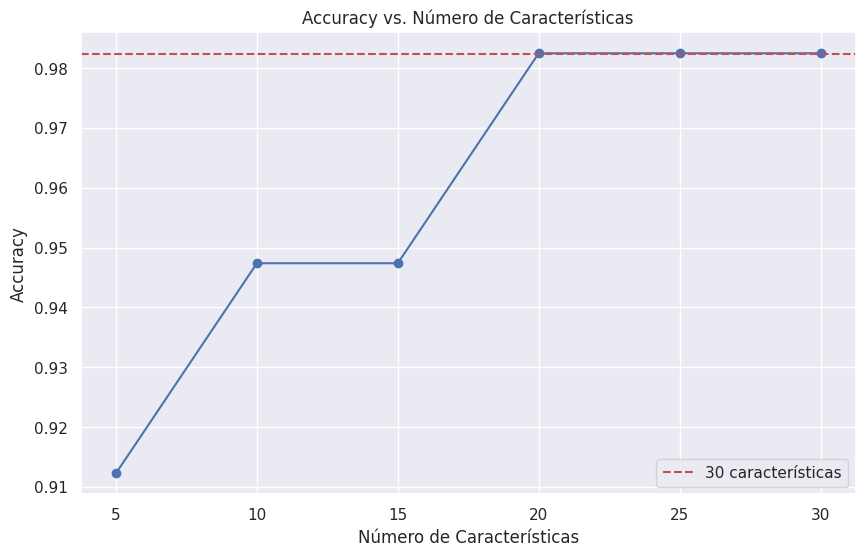

In [ ]:
import matplotlib.pyplot as plt

n_features = [5, 10, 15, 20, 25, 30]
accuracies = []

for n in n_features:
    # Selección RFE con n características
    selector = RFE(model, n_features_to_select=n)
    selector.fit(X_train, y_train)

    # Entrenar modelo reducido
    reduced_model.fit(X_train[:, selector.support_], y_train)
    acc = reduced_model.score(X_test[:, selector.support_], y_test)
    accuracies.append(acc)

# Gráfico de rendimiento
plt.figure(figsize=(10, 6))
plt.plot(n_features, accuracies, 'o-')
plt.axhline(y=0.9824, color='r', linestyle='--', label='30 características')
plt.title('Accuracy vs. Número de Características')
plt.xlabel('Número de Características')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

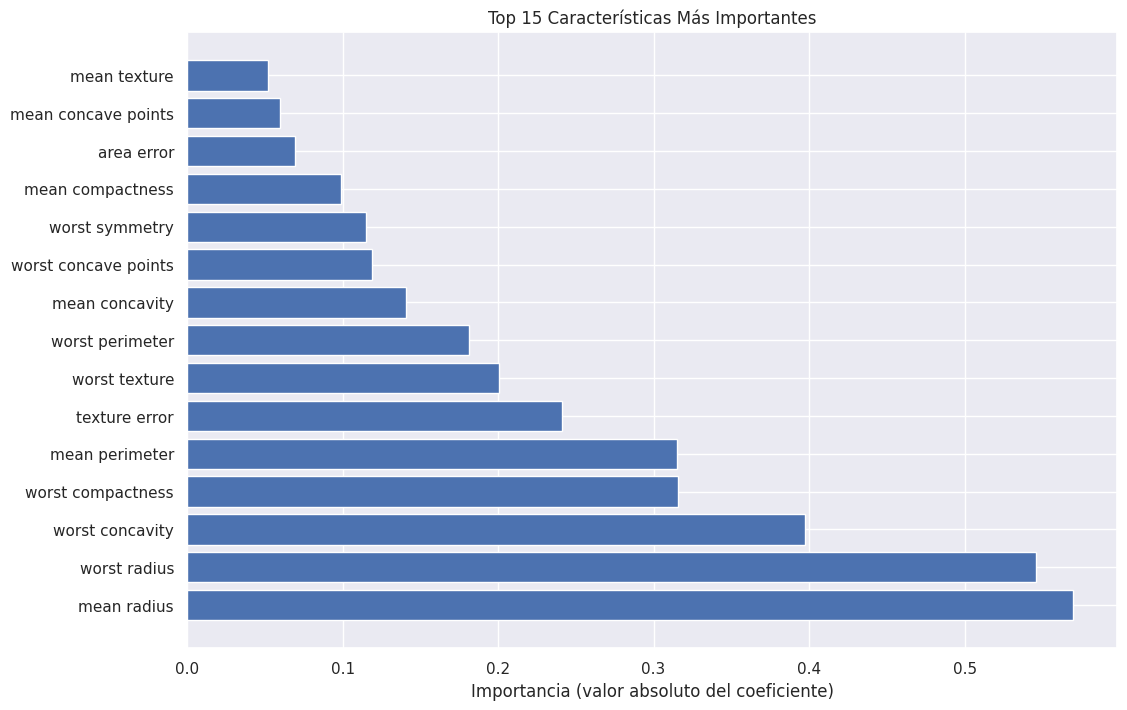

In [ ]:
# Obtener coeficientes del modelo completo
coefs = full_model.coef_[0]
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefs)
}).sort_values('Importance', ascending=False)

# Gráfico de importancia
plt.figure(figsize=(12, 8))
plt.barh(importance['Feature'][:15], importance['Importance'][:15])
plt.title('Top 15 Características Más Importantes')
plt.xlabel('Importancia (valor absoluto del coeficiente)')
plt.show()

Mejora propuesta con mas caracteristicas importantes

In [ ]:
# Seleccionar 15 características con RFE
selector = RFE(model, n_features_to_select=15)
selector.fit(X, y)

# Características seleccionadas
selected_features = feature_names[selector.support_]

# Evaluar rendimiento
reduced_model.fit(X_train[:, selector.support_], y_train)
acc = reduced_model.score(X_test[:, selector.support_], y_test)
print(f"Accuracy con 15 características: {acc:.4f}")

Accuracy con 15 características: 0.9561


## Para seguir leyendo:

- https://pmc.ncbi.nlm.nih.gov/articles/PMC9398810/
- https://medium.com/@shashmikaranam/exploratory-data-analysis-breast-cancer-wisconsin-diagnostic-dataset-6a3be9525cd